In [112]:
import torch
from torch import nn
import os
import hashlib
import re
import collections
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt
import time
import random
from torch.nn import functional as F
import math
from IPython import display

In [20]:
# 8.2节的
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'
DATA_HUB['time_machine'] = (DATA_URL + 'timemachine.txt','090b5e7e70c295757f55df93cb0a180b9691891a')

def download(name,cache_dir=os.path.join('.','data')):
    "下载一个DATA_HUB中的文件返回本地文件名"
    assert name in DATA_HUB,f"{name}不存在于{DATA_HUB}"
    url,sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir,exist_ok=True)
    fname = os.path.join(cache_dir,url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname,'rb') as f:
            while True :
                data = f.read(1048576)
                if not data:
                     break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname
    print(f'正在从{url}下载{fname}...')
    r =  requests.get(url,stream=True,verify=True)
    with open(fname,'wb') as f:
        f.write(r.content)
    return fname

def read_time_machine():
    """将时间机器数据集加载到文本行的列表中"""
    with open(download('time_machine'),'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+',' ',line).strip().lower() for line in lines]

def tokenize(lines,token='word'):
    """将文本行拆分为单词或字符词元"""
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('错误：未知词元类型：'+token)

class Vocab:
    """文本词表"""
    def __init__(self,tokens=None,min_freq=0,reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # 按出现频率排列
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(),key = lambda x:x[1],reverse=True)
        # 未知词元的索引为0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token:idx for idx,token in enumerate(self.idx_to_token)}
        for token,freq in self.token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)
    def __getitem__(self,tokens):
        if not isinstance(tokens,(list,tuple)):
            return self.token_to_idx.get(tokens,self.unk)
        return [self.token_to_idx[token] for token in tokens]
    def to_tokens(self,indices):
        if not isinstance(indices,(list,tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]
    
    @property
    def unk(self):
        return 0
    @property
    def token_freqs(self):
        return self._token_freqs

def count_corpus(tokens):
    """统计词元出现的频率"""
    # 这里的tokens是一维列表或二维列表
    if len(tokens)==0 or isinstance(tokens[0],list):
        # 将词元列表展平成一个列表
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

In [21]:
# 8.3节的
def seq_data_iter_random(corpus,batch_size,num_steps):
    """使用随机抽样生成一个小批量子序列"""
    # 从随机偏移量开始对序列进行分区，随机范围包括num_steps-1
    corpus = corpus[random.randint(0,num_steps-1):]
    # 减去1是因为需要考虑标签
    num_subseqs = (len(corpus)-1)//num_steps
    # 长度为num_steps的子序列的起始索引
    initial_indices = list(range(0,num_subseqs*num_steps,num_steps))
    # 在随机抽样的迭代过程中
    # 来自两个相邻的、随机的、小批量中的子序列不一定在原始序列中相邻
    random.shuffle(initial_indices)

    def data(pos):
        # 返回从pos位置开始的长度为num_steps的序列
        return corpus[pos:pos+num_steps]

    num_batches = num_subseqs//batch_size
    for i in range(0,batch_size*num_batches,batch_size):
        # 在这里，initial_indices包含子序列的随机起始索引
        initial_indices_per_batch = initial_indices[i:i+batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j+1) for j in initial_indices_per_batch]
        yield torch.tensor(X),torch.tensor(Y)

def seq_data_iter_sequential(corpus,batch_size,num_steps):
    """使用顺序分区生成一个小批量子序列"""
    # 从随机偏移量开始拆分序列
    offset = random.randint(0,num_steps)
    num_tokens = ((len(corpus)-offset-1)//batch_size)*batch_size
    Xs = torch.tensor(corpus[offset:offset+num_tokens])
    Ys = torch.tensor(corpus[offset+1:offset+1+num_tokens])
    Xs,Ys = Xs.reshape(batch_size,-1),Ys.reshape(batch_size,-1)
    num_batches = Xs.shape[1]//num_steps
    for i in range(0,num_steps*num_batches,num_steps):
        X = Xs[:,i:i+num_steps]
        Y = Ys[:,i:i+num_steps]
        yield torch.tensor(X),torch.tensor(Y)

def load_corpus_time_machine(max_tokens=-1):  #@save
    """返回时光机器数据集的词元索引列表和词表"""
    lines = read_time_machine()
    tokens = tokenize(lines, 'char')
    vocab = Vocab(tokens)
    # 因为时光机器数据集中的每个文本行不一定是一个句子或一个段落，
    # 所以将所有文本行展平到一个列表中
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

class SeqDataLoader:
    """加载序列数据的迭代器"""
    def __init__(self,batch_size,num_steps,use_random_iter,max_tokens):
        if use_random_iter:
            self.data_iter_fn = seq_data_iter_random
        else:
            self.data_iter_fn = seq_data_iter_sequential
        self.corpus,self.vocab = load_corpus_time_machine(max_tokens)
        self.batch_size,self.num_steps = batch_size,num_steps

    def __iter__(self):
        return self.data_iter_fn(self.corpus,self.batch_size,self.num_steps)

def load_data_time_machine(batch_size, num_steps, use_random_iter=False, max_tokens=10000):
    """返回时光机器数据集的迭代器和词表"""
    data_iter = SeqDataLoader(batch_size, num_steps, use_random_iter, max_tokens)
    return data_iter, data_iter.vocab

In [22]:
batch_size,num_steps =32,35
train_iter,vocab = load_data_time_machine(batch_size,num_steps)

In [58]:
def get_params(vocab_size,num_hiddens,device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape,device=device)*0.01

    def three():
        return (normal((num_inputs,num_hiddens)),normal((num_hiddens,num_hiddens)),torch.zeros(num_hiddens,device=device))

    W_xz,W_hz,b_z = three()  # 更新门参数
    W_xr,W_hr,b_r = three()  # 重置门参数
    W_xh,W_hh,b_h = three()  # 候选隐状态参数
    # 输出层参数
    W_hq = normal((num_hiddens,num_outputs))
    b_q = torch.zeros(num_outputs,device=device)
    # 附加梯度
    params = [W_xz,W_hz,b_z,W_xr,W_hr,b_r,W_xh,W_hh,b_h,W_hq,b_q]
    for param in params:
        param.requires_grad_(True)
    return params

In [59]:
def init_gru_state(batch_size,num_hiddens,device):
    return (torch.zeros((batch_size,num_hiddens),device=device,),)

In [96]:
def gru(inputs,state,params):
    W_xz,W_hz,b_z,W_xr,W_hr,b_r,W_xh,W_hh,b_h,W_hq,b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X@W_xz)+(H@W_hz)+b_z)
        R = torch.sigmoid((X@W_xr)+(H@W_hr)+b_r)
        H_tilda = torch.tanh((X@W_xh)+((R*H)@W_hh)+b_h)
        H = Z*H + (1-Z)*H_tilda
        Y = H@W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs,dim=0),(H,)

In [97]:
def try_gpu(i=0):
    """如果存在，则返回gpu(i)，否则返回cpu()"""
    if torch.cuda.device_count()>=i+1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [98]:
class RNNModelScratch:
    """从零开始实现的循环神经网络模型"""
    def __init__(self,vocab_size,num_hiddens,device,get_params,init_state,forward_fn):
        self.vocab_size,self.num_hiddens = vocab_size,num_hiddens
        self.params = get_params(vocab_size,num_hiddens,device)
        self.init_state,self.forward_fn = init_state,forward_fn
    def __call__(self,X,state):
        X = F.one_hot(X.T,self.vocab_size).type(torch.float32)
        return self.forward_fn(X,state,self.params)
    def begin_state(self,batch_size,device):
        return self.init_state(batch_size,self.num_hiddens,device)

In [99]:
# 辅助函数：计算时间
class Timer:  #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()
    def start(self):
        """启动计时器"""
        self.tik = time.time()
    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]
    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)
    def sum(self):
        """返回时间总和"""
        return sum(self.times)
    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [100]:
# 辅助函数：绘图用
def use_svg_display():
    """使用svg格式在jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()
    
class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: set_axes(self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [101]:
# 辅助函数：累加器
class Accumulator:
    def __init__(self,n):
        self.data = [0.0]*n
    def add(self,*args):
        self.data = [a+float(b) for a,b in zip(self.data,args)]
    def reset(self):
        self.data = [0.0]*len(self.data)
    def __getitem__(self,idx):
        return self.data[idx]

In [102]:
def grad_clipping(net,theta):
    """截断梯度"""
    if isinstance(net,nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta/norm

In [105]:
def sgd(params,lr,batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad/batch_size
            param.grad.zero_()

In [110]:
def predict_ch8(prefix,num_preds,net,vocab,device):
    """在prefix后面生成新字符"""
    state = net.begin_state(batch_size=1,device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda:torch.tensor([outputs[-1]],device=device).reshape((1,1))
    for y in prefix[1:]:
        _,state = net(get_input(),state)
        outputs.append(vocab[y])
    for _ in range(num_preds):
        y,state = net(get_input(),state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

def train_epoch_ch8(net,train_iter,loss,updater,device,use_random_iter):
    """训练网络一轮"""
    state,timer = None,Timer()
    metric = Accumulator(2)
    for X,Y in train_iter:
        if state is None or use_random_iter:
            # 在第一次迭代或使用随机抽样时初始化state
            state = net.begin_state(batch_size=X.shape[0],device=device)
        else:
            if isinstance(net,nn.Module) and not isinstance(state,tuple):
                # state对于nn.GRU是一个张量
                state.detach_()
            else:
                # state对于nn.LSTM或对于我们从零开始实现的模型是一个由张量组成的元组
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X,y = X.to(device),y.to(device)
        y_hat,state = net(X,state)
        l = loss(y_hat,y.long()).mean()
        if isinstance(updater,torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net,1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net,1)
            # 因为已经调用了mean函数
            updater(batch_size=1)
        metric.add(l*y.numel(),y.numel())
    return math.exp(metric[0]/metric[1]),metric[1]/timer.stop()

def train_ch8(net,train_iter,vocab,lr,num_epochs,device,use_random_iter=False):
    """训练模型"""
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch',ylabel='perplexity',legend=['train'],xlim=[10,num_epochs])
    # 初始化
    if isinstance(net,nn.Module):
        updater = torch.optim.SGD(net.parameters(),lr)
    else:
        updater = lambda batch_size:sgd(net.params,lr,batch_size)
    predict = lambda prefix:predict_ch8(prefix,50,net,vocab,device)
    # 训练和预测
    for epoch in range(num_epochs):
        ppl,speed = train_epoch_ch8(net,train_iter,loss,updater,device,use_random_iter)
        if (epoch+1)%10 == 0:
            print(predict('time traveller'))
            animator.add(epoch+1,[ppl])
    print(f'困惑度{ppl:.1f},{speed:.1f} 词元/秒 {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

困惑度1.1,7491.8 词元/秒 cuda:0
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


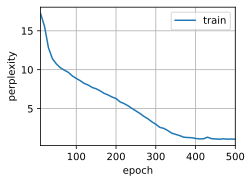

In [113]:
vocab_size,num_hiddens,device = len(vocab),256,try_gpu()
num_epochs,lr = 500,1
model = RNNModelScratch(len(vocab),num_hiddens,device,get_params,init_gru_state,gru)
train_ch8(model,train_iter,vocab,lr,num_epochs,device)

In [ ]:
class RNNModel(nn.Module):
    """循环神经网络模型"""
    def __init__(self,rnn_layer,vocab_size,**kwargs):
        super(RNNModel,self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        # 如果RNN是双向的（之后将介绍），num_directions应该是2，否则应该是1
        if not self.rnn.bidirectional:
            self.num_directions =1
            self.linear = nn.Linear(self.num_hiddens,self.vocab_size)
        else:
            self.num_directions = 2
            self.linear = nn.Linear(self.num_hiddens*2,self.vocab_size)

    def forward(self,inputs,state):
        X = F.one_hot(inputs.T.long(),self.vocab_size)
        X = X.to(torch.float32)
        Y,state = self.rnn(X,state)
        output = self.linear(Y.reshape((-1,Y.shape[-1])))
        return output,state

    def begin_state(self,device,batch_size=1):
        if not isinstance(self.rnn,nn.LSTM):
            return torch.zeros((self.num_directions*self.rnn.num_layers,batch_size,self.num_hiddens),device=device)
        else:
            return (torch.zeros((self.num_directions*self.rnn.num_layers,batch_size,self.num_hiddens),device=device),torch.zeros((self.num_directions*self.rnn.num_layers,batch_size,self.num_hiddens),device=device))

困惑度1.0,68893.7 词元/秒 cuda:0
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


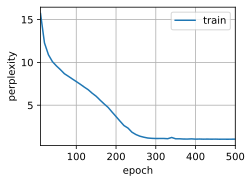

In [114]:
num_inputs = vocab_size
gru_layer = nn.GRU(num_inputs,num_hiddens)
model = RNNModel(gru_layer,len(vocab))
model = model.to(device)
train_ch8(model,train_iter,vocab,lr,num_epochs,device)